# HomeWork -4
## Objective
 In this homework, you will design a python class that encapsulates common univariate/bivariate analysis tasks. You will practice object oriented programing (OOP) while applying descriptive statistics and visualization to summarize your data and explore the relationship between two variables. 
 
 - Use the example provided in the class activity and expand it. The initializer of the class should take data and print out its shape and column names. 
 - Additionally, your class should include at least 5 methods (function) to do either univariate or bivariate analysis of your choice. 
 - Provide markdowns or comments for each part of your code.  

  - Create an instance of your class using Penguin data and use it to analyze it.
  
  - For each analysis you perform, write 1-2 sentence before that function call that clearly state
    the question you are trying to answer with that analysis. For example: "In this analysis I want to see what is the average mass for each species." 

  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
penguins = sns.load_dataset('penguins')

In [50]:
class VariateAnalyzer:
    """Toolkit for Bivariate Analysis"""

    def __init__(self, data): 
        # returns the shape of the data and the names of the columns 
        self.df = data.copy()
        print(f"Shape of data is {len(data)} rows, {len(data.columns)} columns")
        print(f"Columns are: {data.columns}")

    #Quantitative Vs Quantitative
    def quant_scatter(self, x, y, hue = None):
        # bivariate analysis between quantitative variables; modified the class example
        """ Scatterplot with optional color nesting (input third (categorical) as 'hue'), and Correlation """ 
        corr = self.df[[x,y]].corr().iloc[0,1].round(3)
        plt.figure(figsize = (10,6))
        sns.scatterplot(self.df, x = x, y = y, hue = hue)
        plt.title(f"{x} vs {y} ")
        plt.show()
        print(f'The correlation between {x} and {y} is: {corr}') # added in so there's not a random number at the end
        return float(corr); # I don't want Jupyter to autodisplay this as the last line, but I can't seem to stop it. If I don't put float() in front,
        # it presents like this np.float64(0.656). 

    def quant_joint(self, x, y, hue):
        """Joint Plot for two quantitative variables, with optional third categorial variable color nesting"""
        plt.figure(figsize =(12,6))
        sns.jointplot(data = self.df, 
                      x= x,
                      y= y,
                      hue = hue)
        plt.title(f"{y} vs {x}")
        plt.show()
        corr = self.df[[x,y]].corr().iloc[0,1].round(3)
        print(f" The correlation between {x} and {y} is: {corr}.")
        return float(corr);

    # Categorical And Quantitative
    def cat_quant_violin(self, cat, quant, hue = None):
        """ Violinplot: Quantitative data for each category + optional hue nesting,
        also returns means, means do not the third variable into account"""
        # changed the class example bar graph to a violin plot 
        plt.figure(figsize = (8,6))
        sns.violinplot(data = self.df, x = cat, y = quant, hue = hue) # hue creates multiple charts per third variable for each variable in the x 'cat'
        plt.title(f"{cat} vs {quant} ")
        plt.xticks(rotation =45)
        plt.show()
        means = self.df.groupby(cat)[quant].mean().round(1)
        print(f"Means By {cat}: ")
        return means

    def cat_quant_bar(self, cat, quant, estimator, hue = None): 
        # Put 'mean' or 'median' as the estimator to control which stat is used to create the plot
        """ Barplot: Quantitative data for each category, set estimator as 'mean' or 'median' 
        + optional hue nesting"""
        plt.figure(figsize = (8,5))
        sns.barplot(data = self.df, x = cat, y = quant, hue = hue, estimator = estimator) 
        # I wanted to know why our class example was means without us specifying that, and figured out how to change it. 
        plt.title(f"{estimator} {quant} by {cat}" )
        plt.show()
        print(f"{estimator}s by {cat}: ")
        if estimator == 'mean':
            means = self.df.groupby([cat, hue])[quant].agg('mean')
            return means
        else:
            medians = self.df.groupby([cat, hue])[quant].median()
            return medians

    # Categorical vs Categorical 
    def cont_table(self, x, y, margins = True, normalize = False):
        """ creates a frequency table with optional margins column/rows,
        use normalize = False to get a relative frequency table"""
        table = pd.crosstab(self.df[x],self.df[y], margins = margins, normalize = normalize)
        if normalize == False:
            print(f"   Freqency Table: {x} vs {y}")
        else:
            print(f"  Relative Freqency Table: {x} vs {y}")
        print(table)
        return 


## Analysis 

In [51]:
test = VariateAnalyzer(penguins)

Shape of data is 344 rows, 7 columns
Columns are: Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')


### First Instance: What is the correlation between bill length and flipper length? Does species have any effect? 

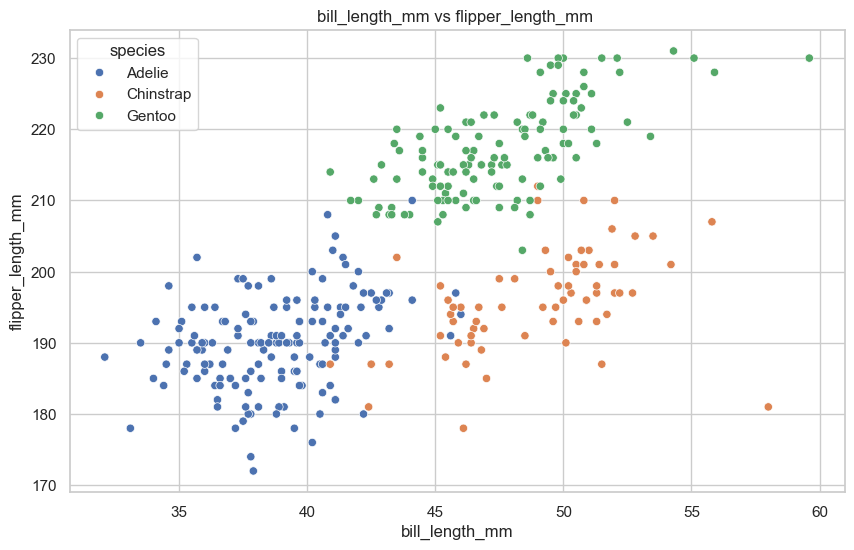

The correlation between bill_length_mm and flipper_length_mm is: 0.656


np.float64(0.656)

In [33]:
test.quant_scatter('bill_length_mm', 'flipper_length_mm', 'species')

There is moderate positive correlation between billl and flipper length. 

## Second Instance: Does the body mass of the penguins vary by home island? How does sex affect body mass? 

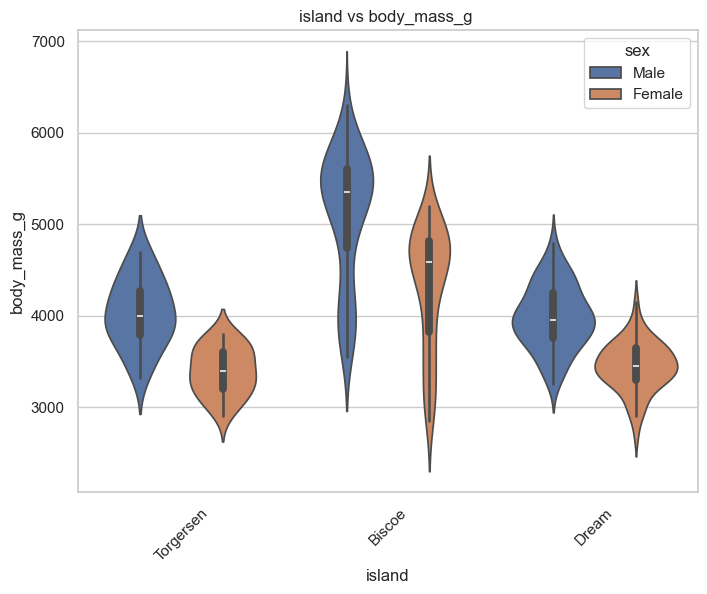

Means By island: 


island
Biscoe       4716.0
Dream        3712.9
Torgersen    3706.4
Name: body_mass_g, dtype: float64

In [34]:
test.cat_quant_violin('island', 'body_mass_g', 'sex')

Yes, body mass varies by island. Biscoe has the largest range, with majority of the penguins being larger than the other two islands' inhabitents. 
Females are generally smaller

### Third Instance: Does the average bill depths vary by island?

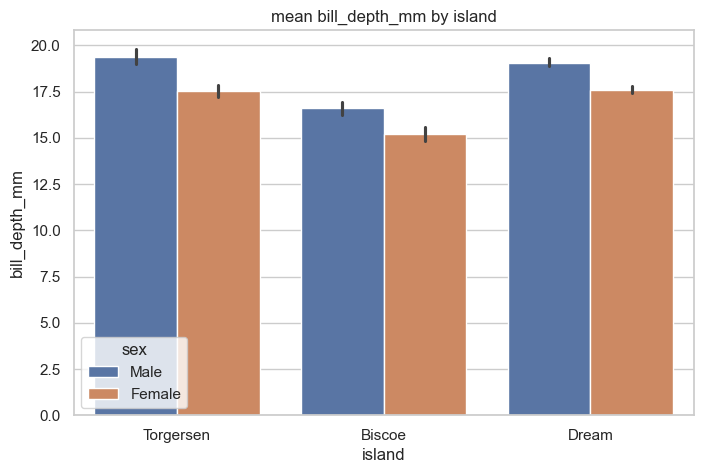

means by island: 


island     sex   
Biscoe     Female    15.191250
           Male      16.597590
Dream      Female    17.601639
           Male      19.066129
Torgersen  Female    17.550000
           Male      19.391304
Name: bill_depth_mm, dtype: float64

In [38]:
test.cat_quant_bar('island', 'bill_depth_mm', 'mean', 'sex')

Bill depth varies very slightly by island, with Biscoe having smaller values than the other two. 
Once again, females tend to have smaller bill depths. 

### Instance Four: What is the correlation of flipper length and body mass? Does sex have any affect?

<Figure size 1200x600 with 0 Axes>

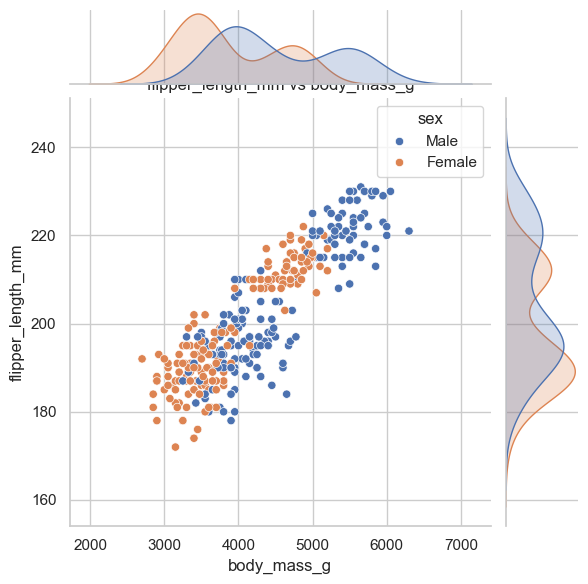

 The correlation between body_mass_g and flipper_length_mm is: 0.871.


0.871

In [49]:
test.quant_joint('body_mass_g', 'flipper_length_mm', 'sex')


There is a strong correlation between flipper length and body mass; which is true for both sexes.

### Instance Five: What is the distribution of penguin species between islands?

In [52]:
test.cont_table('island', 'species', normalize = False)

   Freqency Table: island vs species
species    Adelie  Chinstrap  Gentoo  All
island                                   
Biscoe         44          0     124  168
Dream          56         68       0  124
Torgersen      52          0       0   52
All           152         68     124  344


In [53]:
test.cont_table('island', 'species', normalize = True)

  Relative Freqency Table: island vs species
species      Adelie  Chinstrap    Gentoo       All
island                                            
Biscoe     0.127907   0.000000  0.360465  0.488372
Dream      0.162791   0.197674  0.000000  0.360465
Torgersen  0.151163   0.000000  0.000000  0.151163
All        0.441860   0.197674  0.360465  1.000000


Adelie are on all three islands, while Chinstrap only live on Dream, and Gentoo only live on Biscoe. 
Or, Biscoe is home to Adelie and Gento, Dream is home to Adelie and Chinstrap, and Torgersen only hosts Adelie. 